In [1]:
import sys
sys.path.append(r'../')

from data.data_ISIC_Segment import ISICDataModule
import hao.utils as u
from hao.Segmenter import Segmenter

In [2]:
image_dir = r'C:\Users\HaoXL\Music\ISIC\2018\Training_Data\ISIC2018_Task1-2_Training_Input'
mask_dir = r'C:\Users\HaoXL\Music\ISIC\2018\Training Ground Truth\ISIC2018_Task1_Training_GroundTruth\ISIC2018_Task1_Training_GroundTruth'
last_model_path = r'model_pth/last_model.pth'
best_model_path = r'model_pth/best_model.pth'

img_size, patch_size, batch_size = 224, 16, 64
num_workers = 8
max_epochs = 15
use_bias = False
restart_train = False
gpu_idx = 0
num_hiddens, num_heads, num_blks = 512, 4, 3
mlp_num_hiddens = num_hiddens * 4
emb_dropout, blk_dropout, lr = 0.1, 0.1, 1e-3
num_classes = 2

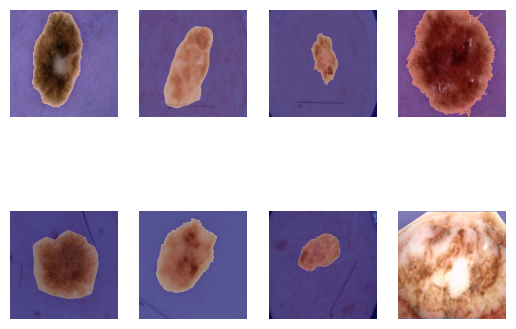

In [3]:
data = ISICDataModule(image_dir, mask_dir, batch_size, img_size, num_workers)
train_loader = data.get_dataloader(train=True)
test_loader = data.get_dataloader(train=False)

batch = next(iter(train_loader))
data.visualize(batch, nrows=2, ncols=4)

In [4]:
batch[0].shape

torch.Size([64, 3, 224, 224])

In [5]:
batch[1].shape

torch.Size([64, 1, 224, 224])

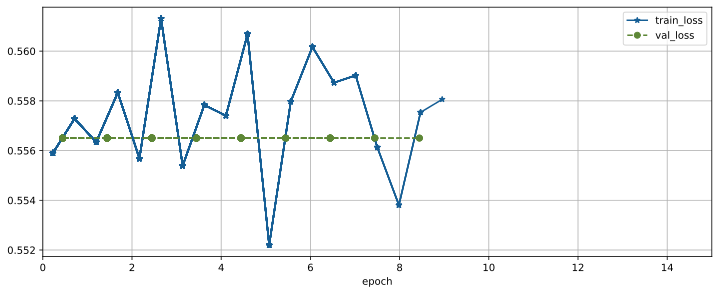

In [ ]:
model = Segmenter(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout, num_classes, lr)
trainer = u.Trainer_Seg(max_epochs, last_model_path, best_model_path, restart_train, gpu_idx)
trainer.fit(model, data)
